#### 从 Node 中发送自定义数据

In [1]:
from typing import TypedDict
from langgraph.config import get_stream_writer
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    query: str
    answer: str

def node(state: State):
    # Get the stream writer to send custom data
    writer = get_stream_writer()
    # Emit a custom key-value pair (e.g., progress update)
    writer({"custom_key": "Generating custom data inside node"})
    return {"answer": "some data"}

graph = (
    StateGraph(State)
    .add_node(node)
    .add_edge(START, "node")
    .add_edge("node", END)
    .compile()
)

In [2]:
inputs = {"query": "example"}

# Set stream_mode="custom" to receive the custom data in the stream
for chunk in graph.stream(inputs, stream_mode="custom", version="v2"): # type: ignore
    if chunk["type"] == "custom":
        print(f"Custom event: {chunk['data']['custom_key']}")

Custom event: Generating custom data inside node


#### 从工具调用中发送自定义数据

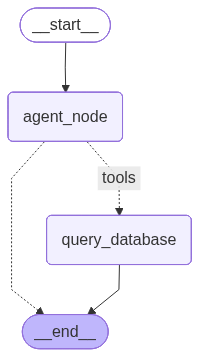

In [3]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from agent_lab.model_hub import LLM_FAST
from IPython.display import Image, display


@tool
def query_database(query: str) -> str:
    """Query the database."""
    # Access the stream writer to send custom data
    writer = get_stream_writer()
    # Emit a custom key-value pair (e.g., progress update)
    writer({"data": "Retrieved 0/100 records", "type": "progress"})
    # perform query
    # Emit another custom key-value pair
    writer({"data": "Retrieved 100/100 records", "type": "progress"})
    return "some-answer"

llm = init_chat_model(**LLM_FAST).bind_tools([query_database])

def agent_node(state: MessagesState):
    response = llm.invoke(state['messages'])
    return {"messages": [response]}

graph = (
    StateGraph(MessagesState)
    .add_node(agent_node)
    .add_node('query_database', ToolNode([query_database]))
    .add_edge(START, "agent_node")
    .add_conditional_edges(
        'agent_node',
        tools_condition,
        {'tools': 'query_database', END: END},
    )
    .add_edge("query_database", END)
    .compile()
)
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
# Set stream_mode="custom" to receive the custom data in the stream
inp = {"messages": [{"role": "user", "content": "query the database with a arbitrary query for testing."}]}
for chunk in graph.stream(inp, stream_mode="custom", version="v2"): # type: ignore
    if chunk["type"] == "custom":
        print(f"{chunk['data']['type']}: {chunk['data']['data']}")

progress: Retrieved 0/100 records
progress: Retrieved 100/100 records
